### **Full-Batch GraphSAGE**

#### Import libraries and set up the system.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import random
import math
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import to_undirected
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, classification_report
)

# GPU or CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Random seed (giống GCN) ──────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cpu


#### Load PyG data

In [2]:
from torch_geometric.utils import to_undirected

data = torch.load('../data/processed/pyg_data.pt')

# ── Undirected (giống GCN) ───────────────────────────────────────────────────
data.edge_index = to_undirected(data.edge_index)

# ── Z-score normalization trên train features (giống GCN) ───────────────────
train_features = data.x[data.train_mask]
train_mean = train_features.mean(dim=0)
train_std  = train_features.std(dim=0)
data.x = (data.x - train_mean) / (train_std + 1e-8)

print(data)
data = data.to(device)

Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define GraphSAGE

In [3]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, aggregator_type='mean', dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=aggregator_type)
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr=aggregator_type)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Layer 2
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGE(
    in_channels=data.x.shape[1],
    hidden_channels=64,
    out_channels=2,
    aggregator_type='mean',  # mean, gcn, max, lstm
    dropout=0.5
).to(device)

print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

GraphSAGE(
  (conv1): SAGEConv(165, 64, aggr=mean)
  (conv2): SAGEConv(64, 2, aggr=mean)
)
Number of parameters: 21,442


#### Optimizer and Loss function

In [4]:
import math

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

n_licit   = (data.y[data.train_mask] == 0).sum().item()
n_illicit = (data.y[data.train_mask] == 1).sum().item()

weight = torch.tensor([1.0, math.sqrt(n_licit / n_illicit)], dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weight)

print(weight)

tensor([1.0000, 2.8616])


#### Train/Evaluate function

In [5]:
def train_one_epoch():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1)
    probs = F.softmax(out[mask], dim=1)[:, 1]  # probability of illicit
    y_true = data.y[mask].cpu().numpy()
    y_pred = pred.cpu().numpy()
    y_prob = probs.cpu().numpy()
    loss = criterion(out[mask], data.y[mask]).item()

    acc           = accuracy_score(y_true, y_pred)
    precision_ill = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_ill    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_ill        = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_macro      = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc_pr        = average_precision_score(y_true, y_prob)
    return {
        'loss': loss, 'accuracy': acc,
        'precision_ill': precision_ill, 'recall_ill': recall_ill,
        'f1_ill': f1_ill, 'f1_macro': f1_macro, 'auc_pr': auc_pr,
    }

#### Training with Early Stopping and Saving the Best Model

In [6]:
NUM_EPOCHS = 200
PATIENCE = 20

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
monitor_metric = 'f1_ill'
best_val_score = 0.0
epochs_no_improve = 0
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch()

    train_metrics = evaluate(data.train_mask)
    val_metrics   = evaluate(data.val_mask)

    train_f1 = train_metrics['f1_ill']
    val_f1   = val_metrics['f1_ill']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    if val_metrics[monitor_metric] > best_val_score:
        best_val_score = val_metrics[monitor_metric]
        best_epoch = epoch
        torch.save(model.state_dict(), '../saved_models/graphsage_best.pt')  # ← tên file giữ nguyên
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, "
          f"Train F1={train_f1:.4f}, Val F1={val_f1:.4f}, "
          f"Gap={train_f1 - val_f1:.4f}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (Best epoch: {best_epoch})")
        break

print(f"\nBest Val {monitor_metric}: {best_val_score:.4f} at epoch {best_epoch}")
print(f"Train F1 at best epoch: {history['train_f1'][best_epoch-1]:.4f}")
print(f"Val   F1 at best epoch: {history['val_f1'][best_epoch-1]:.4f}")
print(f"Gap at best epoch: {history['train_f1'][best_epoch-1] - history['val_f1'][best_epoch-1]:.4f}")

Epoch 001: Train Loss=0.6579, Train F1=0.5455, Val F1=0.4444, Gap=0.1010
Epoch 002: Train Loss=0.3782, Train F1=0.6421, Val F1=0.5985, Gap=0.0437
Epoch 003: Train Loss=0.3201, Train F1=0.6874, Val F1=0.5933, Gap=0.0941
Epoch 004: Train Loss=0.2930, Train F1=0.6859, Val F1=0.5521, Gap=0.1338
Epoch 005: Train Loss=0.2717, Train F1=0.6785, Val F1=0.5382, Gap=0.1403
Epoch 006: Train Loss=0.2535, Train F1=0.6956, Val F1=0.5566, Gap=0.1390
Epoch 007: Train Loss=0.2341, Train F1=0.7253, Val F1=0.6020, Gap=0.1233
Epoch 008: Train Loss=0.2228, Train F1=0.7543, Val F1=0.6488, Gap=0.1055
Epoch 009: Train Loss=0.2201, Train F1=0.7632, Val F1=0.6600, Gap=0.1031
Epoch 010: Train Loss=0.2105, Train F1=0.7556, Val F1=0.6464, Gap=0.1092
Epoch 011: Train Loss=0.2037, Train F1=0.7517, Val F1=0.6401, Gap=0.1116
Epoch 012: Train Loss=0.1980, Train F1=0.7598, Val F1=0.6424, Gap=0.1174
Epoch 013: Train Loss=0.1917, Train F1=0.7848, Val F1=0.6711, Gap=0.1137
Epoch 014: Train Loss=0.1773, Train F1=0.8084, Val 

#### Learning curve

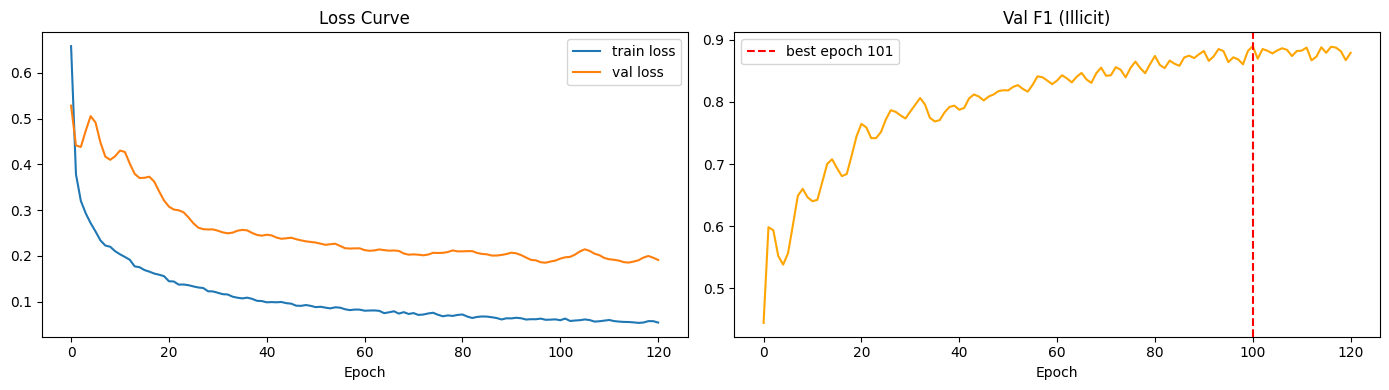

In [7]:
import os

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['train_loss'], label='train loss')
ax1.plot(history['val_loss'], label='val loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['val_f1'], color='orange')
ax2.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'best epoch {best_epoch}')
ax2.set_title('Val F1 (Illicit)')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
save_dir = '../reports/figures'
file_path = f'{save_dir}/graphsage_training_curve.png'
os.makedirs(save_dir, exist_ok=True)

plt.savefig(file_path, dpi=150)
plt.show()

#### Evaluation on Test Set

In [9]:
model.load_state_dict(torch.load('../saved_models/graphsage_best.pt'))

test_metrics = evaluate(data.test_mask)

print(f"Test Accuracy:          {test_metrics['accuracy']:.4f}")
print(f"Test Precision (Ill):   {test_metrics['precision_ill']:.4f}")
print(f"Test Recall (Ill):      {test_metrics['recall_ill']:.4f}")
print(f"Test F1-Illicit:        {test_metrics['f1_ill']:.4f}")
print(f"Test F1-macro:          {test_metrics['f1_macro']:.4f}")
print(f"Test AUC-PR:            {test_metrics['auc_pr']:.4f}")

Test Accuracy:          0.9346
Test Precision (Ill):   0.4970
Test Recall (Ill):      0.6057
Test F1-Illicit:        0.5460
Test F1-macro:          0.7554
Test AUC-PR:            0.5487
